# Imports

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Data Preperation

In [3]:
df = pd.read_csv("../00_Productive_Data/charging_data_clean.csv")
df_weather = pd.read_csv("../00_Productive_Data/weather_data_clean.csv")

In [4]:
df.dtypes

Unnamed: 0            int64
id                   object
connectionTime       object
disconnectTime       object
doneChargingTime     object
kWhDelivered        float64
sessionID            object
siteID                int64
spaceID              object
timezone             object
userID              float64
userInputs           object
dtype: object

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60922 entries, 0 to 60921
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        60922 non-null  int64  
 1   id                60922 non-null  object 
 2   connectionTime    60922 non-null  object 
 3   disconnectTime    60922 non-null  object 
 4   doneChargingTime  60922 non-null  object 
 5   kWhDelivered      60922 non-null  float64
 6   sessionID         60922 non-null  object 
 7   siteID            60922 non-null  int64  
 8   spaceID           60922 non-null  object 
 9   timezone          60922 non-null  object 
 10  userID            44637 non-null  float64
 11  userInputs        44637 non-null  object 
dtypes: float64(2), int64(2), object(8)
memory usage: 5.6+ MB


In [6]:
df_weather.dtypes

Unnamed: 0                   int64
timestamp                   object
temperature                float64
cloud_cover                float64
cloud_cover_description     object
pressure                   float64
windspeed                  float64
precipitation              float64
felt_temperature           float64
dtype: object

In [7]:
df.head()

,Unnamed: 0,id,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,timezone,userID,userInputs
0,52871,5c36631ef9af8b4639a8e5bc,2018-10-08 15:44:47-07:00,2018-10-08 17:59:14-07:00,2018-10-08 17:56:20-07:00,10.208,1_1_193_825_2018-10-08 22:44:47.505042,1,AG-1F01,America/Los_Angeles,NaN,NaN
1,52886,5c366352f9af8b4639a8e5cb,2018-10-09 06:08:55-07:00,2018-10-09 15:03:56-07:00,2018-10-09 10:33:24-07:00,11.837,1_1_193_825_2018-10-09 13:08:55.279362,1,AG-1F01,America/Los_Angeles,NaN,NaN
2,52942,5c366352f9af8b4639a8e603,2018-10-09 15:26:40-07:00,2018-10-09 19:48:12-07:00,2018-10-09 19:28:29-07:00,12.034,1_1_193_825_2018-10-09 22:26:39.626134,1,AG-1F01,America/Los_Angeles,383.0,"[{'WhPerMile': 400, 'kWhRequested': 15.2, 'mil..."
3,52958,5c36639ff9af8b4639a8e613,2018-10-10 06:15:02-07:00,2018-10-10 15:30:44-07:00,2018-10-10 10:56:11-07:00,11.985,1_1_193_825_2018-10-10 13:15:01.608497,1,AG-1F01,America/Los_Angeles,NaN,NaN
4,53015,5c36639ff9af8b4639a8e64c,2018-10-10 15:52:56-07:00,2018-10-10 17:34:00-07:00,2018-10-10 17:11:04-07:00,7.863,1_1_193_825_2018-10-10 22:52:55.607786,1,AG-1F01,America/Los_Angeles,NaN,NaN


In [8]:
df["connectionTime"] = pd.to_datetime(df["connectionTime"], errors="coerce", utc=True)\
                           .dt.tz_convert("America/Los_Angeles")

df["disconnectTime"] = pd.to_datetime(df["disconnectTime"], errors="coerce", utc=True)\
                           .dt.tz_convert("America/Los_Angeles")

df['chargingDuration'] = (df['disconnectTime'] - df['connectionTime']).dt.total_seconds() / 3600

df['connection_date'] = df['connectionTime'].dt.normalize()

df_weather['timestamp'] = pd.to_datetime(df_weather['timestamp'], errors="coerce", utc=True)\
                            .dt.tz_convert("America/Los_Angeles")

In [9]:
df.dtypes

Unnamed: 0                                        int64
id                                               object
connectionTime      datetime64[ns, America/Los_Angeles]
disconnectTime      datetime64[ns, America/Los_Angeles]
doneChargingTime                                 object
kWhDelivered                                    float64
sessionID                                        object
siteID                                            int64
spaceID                                          object
timezone                                         object
userID                                          float64
userInputs                                       object
chargingDuration                                float64
connection_date     datetime64[ns, America/Los_Angeles]
dtype: object

In [10]:
df_weather.dtypes

Unnamed: 0                                               int64
timestamp                  datetime64[ns, America/Los_Angeles]
temperature                                            float64
cloud_cover                                            float64
cloud_cover_description                                 object
pressure                                               float64
windspeed                                              float64
precipitation                                          float64
felt_temperature                                       float64
dtype: object

# Descriptive Analytics

### Compare Charging durations

In [11]:
site_stats = df.groupby('siteID')[['chargingDuration', 'kWhDelivered']].mean()
print(site_stats)

        chargingDuration  kWhDelivered
siteID                                
1               6.871554     14.164149
2               5.844028      8.812310


### Compare missing User IDs

   siteID  userID_missing
0       1            1433
1       2           14852


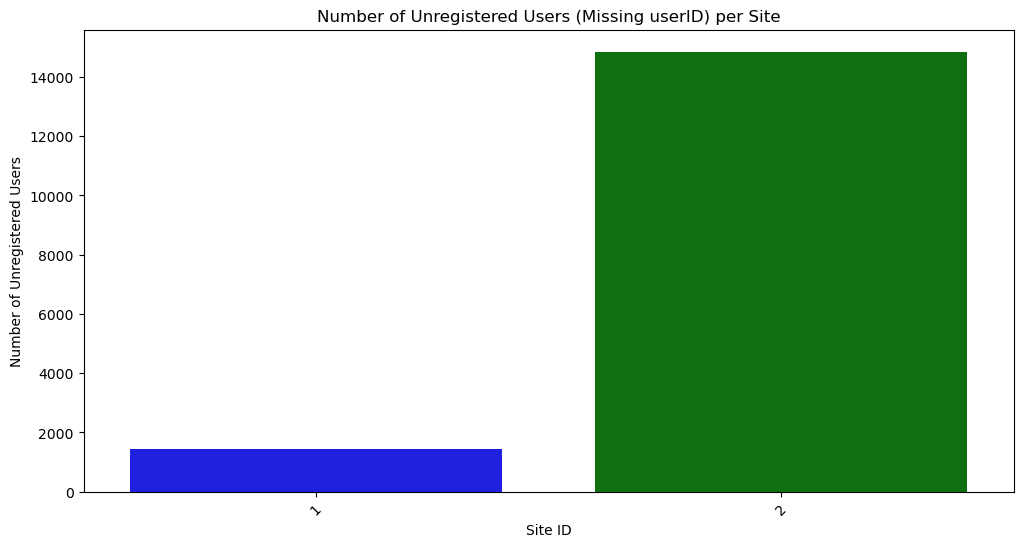

In [12]:
df['userID_missing'] = df['userID'].isnull()

unregistered_users_per_site = df.groupby('siteID')['userID_missing'].sum().reset_index()
print(unregistered_users_per_site)


plt.figure(figsize=(12, 6))
sns.barplot(x='siteID', y='userID_missing', hue='siteID', data=unregistered_users_per_site, palette=['blue', 'green'], dodge=False, legend=False)
plt.title('Number of Unregistered Users (Missing userID) per Site')
plt.xlabel('Site ID')
plt.ylabel('Number of Unregistered Users')
plt.xticks(rotation=45)
plt.show()

Site 1:
Has a low number of unregistered users, suggesting it is likely a private hub where users are required to register or obtain authorization for access before charging.

Site 2:
Has a high number of sessions with missing user information, suggesting that the site serves many unregistered or occasional users, possibly due to being a more publicly accessible charging station.


### Compare Charging over Time (Errorneous, possibly needs fixing?)

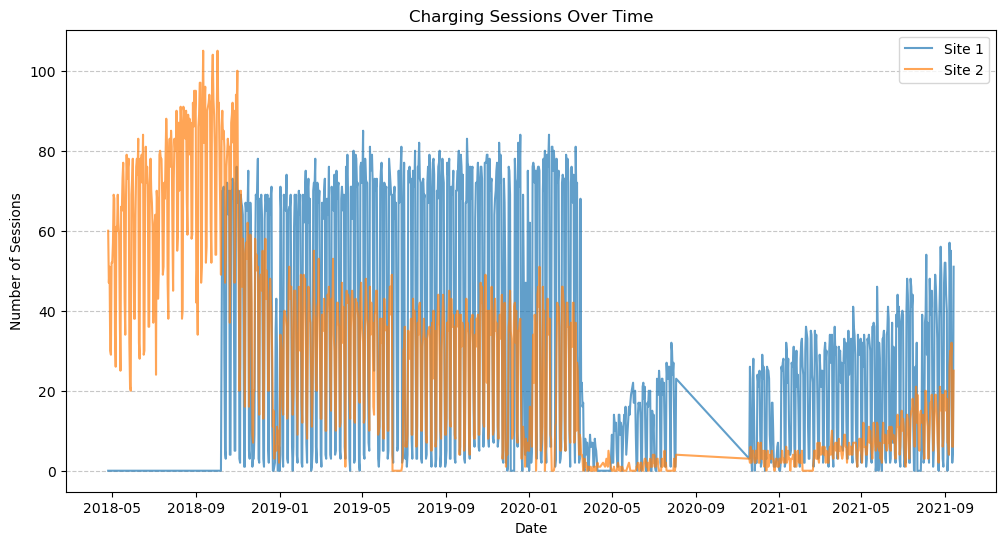

In [13]:
df['connection_date'] = df['connectionTime'].dt.date

charging_sessions_per_day = df.groupby(['connection_date', 'siteID']).size().unstack(fill_value=0)

plt.figure(figsize=(12, 6))
for siteID in charging_sessions_per_day.columns:
    charging_sessions_per_day[siteID].plot(label=f'Site {siteID}', alpha=0.7)
plt.title('Charging Sessions Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Sessions')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


Site 1:
Has a higher number of charging sessions, suggesting that it may experience greater demand or serve a larger user base, possibly due to better accessibility or higher usage rates.

Site 2:
Has a lower number of charging sessions, with a noticeable drop-off after Site 1 opened. This suggests that users may be shifting to Site 1, potentially due to different factors (e.g. better facilities, location, convenience) offered at Site 1, leading to a decline in Site 2's activity.

### Compare charging durations

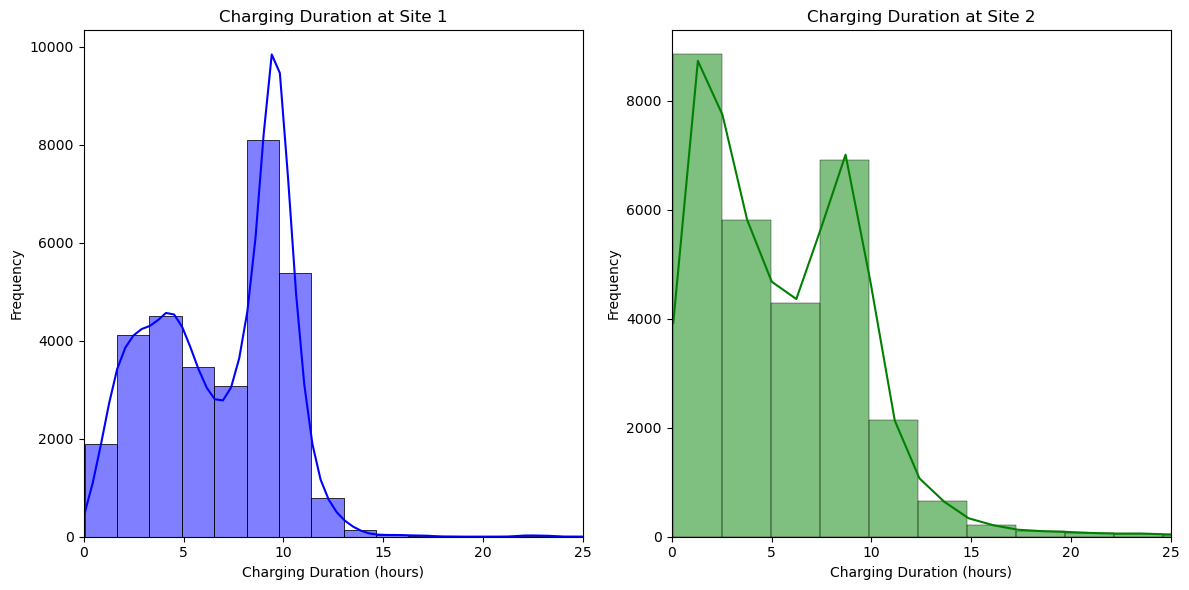

In [14]:
site1_data = df[df['siteID'] == 1]
site2_data = df[df['siteID'] == 2]

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.histplot(site1_data['chargingDuration'], bins=50, kde=True, color='blue')
plt.title("Charging Duration at Site 1")
plt.xlabel("Charging Duration (hours)")
plt.ylabel("Frequency")
plt.xlim(0, 25) 

plt.subplot(1, 2, 2)
sns.histplot(site2_data['chargingDuration'], bins=100, kde=True, color='green')
plt.title("Charging Duration at Site 2")
plt.xlabel("Charging Duration (hours)")
plt.ylabel("Frequency")
plt.xlim(0, 25) 

plt.tight_layout()
plt.show()


Site 1: 
Has significantly longer charging durations, suggesting a user base comprised of residents or employees who require long-term parking. This indicates a more stable and predictable usage pattern, possibly due to the site being located at a primary destination where users spend their workday or overnight hours.

Site 2: 
Has much shorter charging durations, suggesting it functions as a public transit hub for quick "top-up" sessions. This indicates a high-turnover environment, possibly due to its location serving transient users who prioritize a fast session to continue their journey rather than a long-stay connection.

### Compare charging times

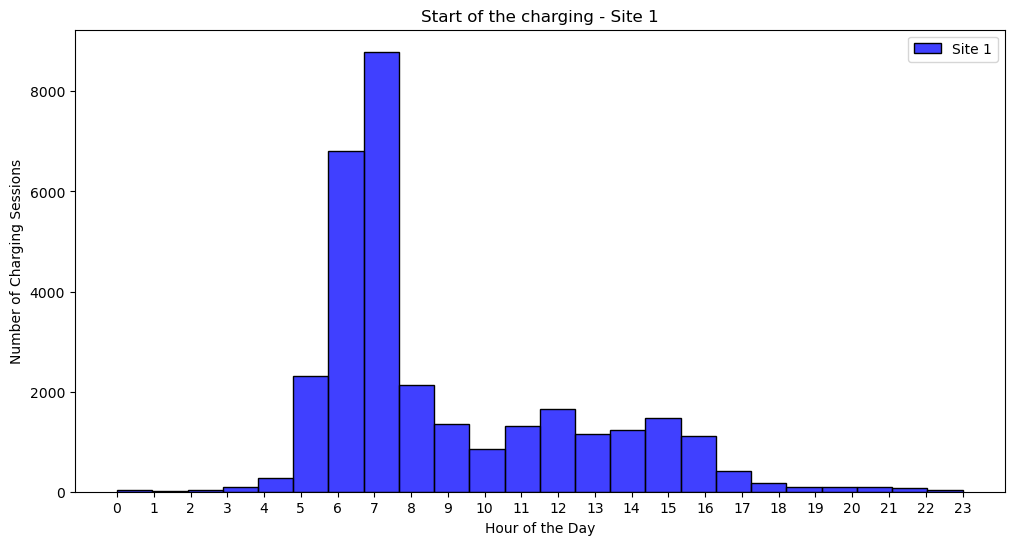

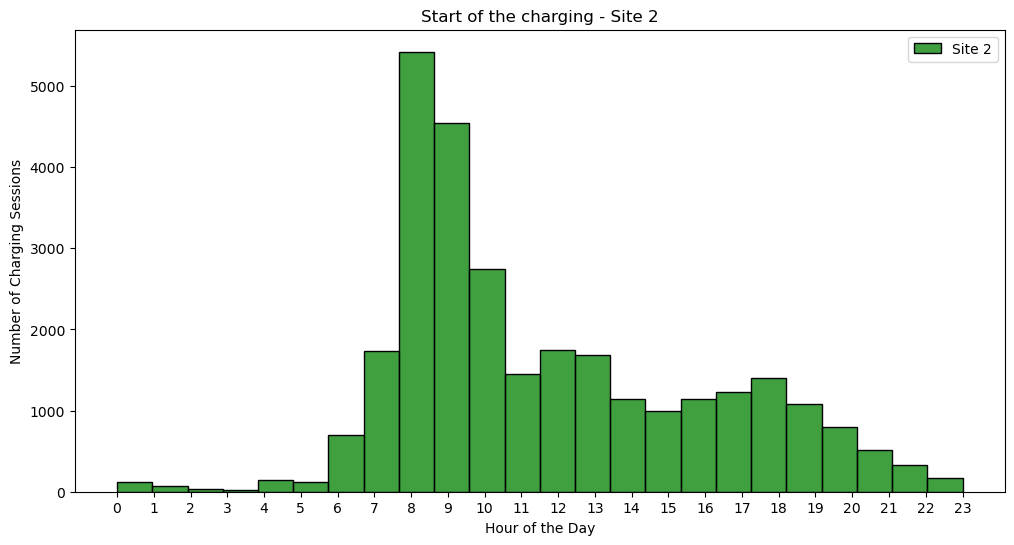

In [15]:
df['chargingHour'] = df['connectionTime'].dt.hour

site1_data = df[df['siteID'] == 1]
site2_data = df[df['siteID'] == 2]

plt.figure(figsize=(12, 6))
sns.histplot(site1_data['chargingHour'].dropna(), bins=24, kde=False, color='blue', label='Site 1')
plt.title('Start of the charging - Site 1')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Charging Sessions')
plt.xticks(range(0, 24))
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))
sns.histplot(site2_data['chargingHour'].dropna(), bins=24, kde=False, color='green', label='Site 2')
plt.title('Start of the charging - Site 2')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Charging Sessions')
plt.xticks(range(0, 24))
plt.legend()
plt.show()


Site 1:
Has more concentrated charging times with distinct peak hours, suggesting a highly predictable and routine usage schedule. This indicates a consistent user base with well-established charging habits, possibly due to the site serving as a private hub for employees or residents who plug in during fixed work shifts or overnight.

Site 2: 
Has a greater variability in charging times throughout the day, suggesting that usage is driven by more sporadic and diverse demand. This indicates an on-demand service model rather than a routine-based one, possibly due to its function as a public hub catering to transient customers who charge based on immediate need rather than a set schedule.


### Compare charging sessions across the seasons (is this correct?)

C:\Users\micha\AppData\Local\Temp\ipykernel_13232\751848506.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


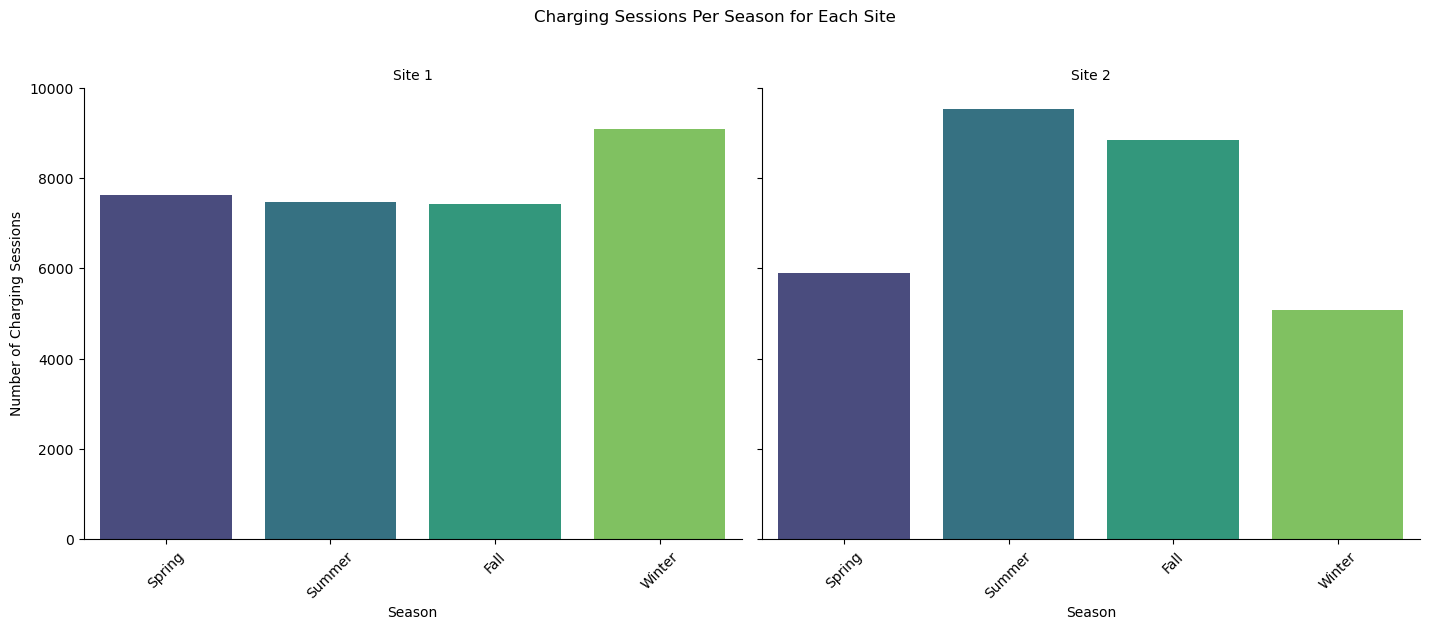

In [16]:
df['month'] = df['connectionTime'].dt.month

def get_season(month):
    if month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    elif month in [9, 10, 11]:
        return 'Fall'
    else:
        return 'Winter'

df['season'] = df['month'].apply(get_season)
season_order = ['Spring', 'Summer', 'Fall', 'Winter']
season_data = df.groupby(['season', 'siteID']).size().reset_index(name='session_count')

g = sns.catplot(
    data=season_data,
    x='season',
    y='session_count',
    col='siteID',
    kind='bar',
    order=season_order,
    height=6,
    aspect=1.2,
    palette='viridis',
    sharey=True  
)

g.set_titles("Site {col_name}")
g.set_axis_labels("Season", "Number of Charging Sessions")
g.set_xticklabels(rotation=45)
plt.subplots_adjust(top=0.85)
g.fig.suptitle("Charging Sessions Per Season for Each Site")

plt.show()

Site 1: 
Has a big peak in charging sessions during the Winter season, suggesting a sharp increase in demand during colder months. This indicates a high level of seasonal sensitivity, possibly due to decreased battery efficiency in lower temperatures or a consistent group of users-like residents-increasing their charging frequency to maintain range during the winter.

Site 2: 
Has a primary peak in the Summer, suggesting usage patterns tied to seasonal transit or leisure activities. This indicates a different demand driver than Site 1, possibly due to its role as a public hub serving transient users who are more active during summer travel months.

### Compare number of visits per customer

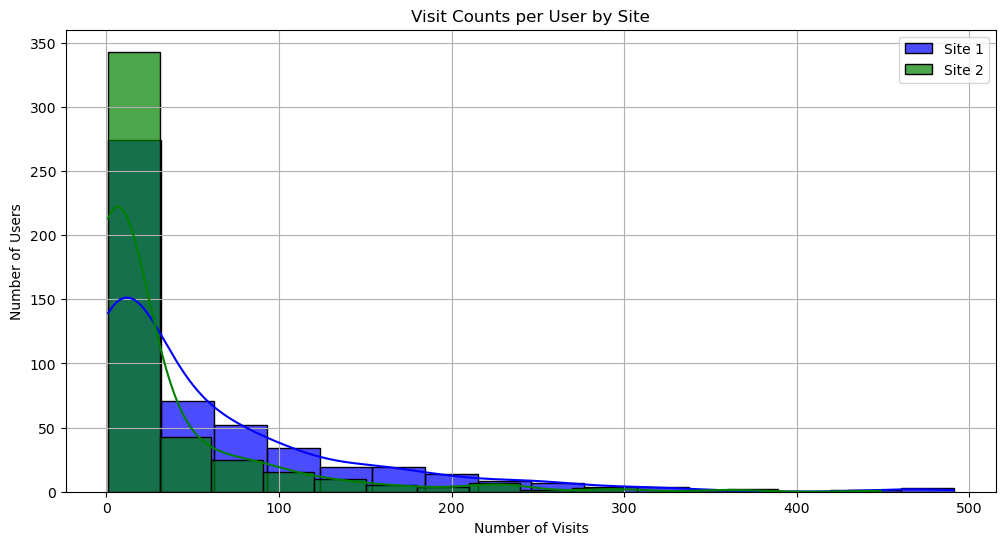

In [17]:
visit_counts = df.groupby(['siteID', 'userID']).size().reset_index(name='visit_count')

site1_visits = visit_counts[visit_counts['siteID'] == 1]
site2_visits = visit_counts[visit_counts['siteID'] == 2]

plt.figure(figsize=(12, 6))

sns.histplot(data=site1_visits, x='visit_count', kde=True, color='blue', label='Site 1', binwidth=30, alpha=0.7)
sns.histplot(data=site2_visits, x='visit_count', kde=True, color='green', label='Site 2', binwidth=30, alpha=0.7)

plt.title("Visit Counts per User by Site")
plt.xlabel("Number of Visits")
plt.ylabel("Number of Users")
plt.legend()
plt.grid(True)
plt.show()

Site 1:
Higher proportion of frequent users compared to Site 2, suggesting that this site caters to a consistent user base (e.g. employees or residents), who rely on this charging hub regularly.

Site 2:
Fewer frequent users, indicating that the site serves a more diverse and transient customer base, likely driven by occasional or on-demand charging needs

# Conclusion


Site 1: 
Has concentrated charging peaks, longer session durations, and a high frequency of registered users, suggesting that it functions as a dedicated private charging hub. This indicates a stable and routine-oriented user base, possibly due to the site serving employees or residents who rely on the station for predictable, regular charging as part of their daily schedule.

Site 2: 
Has high variability in charging times, shorter session durations, and a significant proportion of unregistered users, suggesting that it operates as a high-turnover public charging hub. This indicates a demand driven by sporadic, on-demand needs, possibly due to its role serving transient customers or tourists whose charging habits are influenced by external seasonal factors rather than a set routine.